# Prepare dataset

In [10]:
input_pages = '../output/dataset/pages-reviewed.jsonl'

In [11]:
import json
from dataclasses import dataclass
import numpy as np


@dataclass
class Line:
    character: str
    text: str
    confidence: float
    uno_confidence: float
    reviewed: bool = False

    def to_dict(self) -> dict:
        return {
            'character': self.character,
            'text': self.text,
            'confidence': self.confidence,
            'uno_confidence': self.uno_confidence,
            'reviewed': self.reviewed
        }

    @staticmethod
    def from_dict(data: dict) -> 'Line':
        return Line(
            character=data['character'],
            text=data['text'],
            confidence=data['confidence'],
            uno_confidence=data.get('uno_confidence', 0.0),
            reviewed=data.get('reviewed', False)
        )


@dataclass
class Page:
    input_page: str
    pkna: str
    page_num: int
    conv_num: int
    dialogue: list[Line]

    def to_dict(self) -> dict:
        return {
            'input_page': self.input_page,
            'pkna': self.pkna,
            'page_num': self.page_num,
            'conv_num': self.conv_num,
            'dialogue': [d.to_dict() for d in self.dialogue]
        }

    @staticmethod
    def from_dict(data: dict) -> 'Page':
        return Page(
            input_page=data['input_page'],
            pkna=data['pkna'],
            page_num=data['page_num'],
            conv_num=data['conv_num'],
            dialogue=[Line.from_dict(line) for line in data['dialogue']]
        )


# Load pages from the input file
with open(input_pages, 'r', encoding='utf-8') as f:
    pages = [
        Page.from_dict(json.loads(line))
        for line in f
    ]

## Join pages into conversations

In [21]:
@dataclass
class Conversation:
    pages: list[Page]
    score: float = 0.0

    @property
    def characters(self) -> list[str]:
        """Get the set of characters in the conversation."""
        return sorted(list({
            line.character
            for page in self.pages
            for line in page.dialogue
        }))

    @property
    def characters_score(self) -> int:
        wanted = set(['uno', 'paperinik'])
        got = set(self.characters)
        positive = got.intersection(wanted)
        negative = got.difference(wanted)
        return len(positive)*3 - len(negative)

    @property
    def num_pages_score(self) -> int:
        return len(self.pages)

    @property
    def confidence_score(self) -> float:
        """Calculate the average confidence of the conversation."""
        confidences = [
            np.mean([line.confidence for line in page.dialogue])
            for page in self.pages
        ]
        return float(np.mean(confidences)) if confidences else 0.0

    def to_dict(self) -> dict:
        return {
            'pkna': self.pages[0].pkna,
            'page_range': [page.page_num for page in self.pages],
            'characters': self.characters,
            'score': self.score,
            'pages': [page.to_dict() for page in self.pages]
        }


conversations = []

curr_conv: list[Page] = []

for page in pages:
    if curr_conv and (curr_conv[-1].page_num + 1) != page.page_num:
        conversations.append(Conversation(pages=curr_conv))
        curr_conv = []
    curr_conv.append(page)
if curr_conv:
    conversations.append(Conversation(pages=curr_conv))

len(conversations)

391

In [22]:
# Compute the score through combination of softmax of the three scores
import numpy as np


def softmax(nums: list[int | float]) -> list[float]:
    exp_scores = np.exp(nums - np.max(nums))
    softmax_scores = exp_scores / np.sum(exp_scores)
    return softmax_scores.tolist()


def compute_scores(conversations: list[Conversation]) -> None:
    char_scores = softmax([c.characters_score for c in conversations])
    num_pages_scores = softmax([c.num_pages_score for c in conversations])
    confidence_scores = softmax([c.confidence_score for c in conversations])

    for i, conv in enumerate(conversations):
        conv.score = (
            0.4 * confidence_scores[i] +
            0.4 * char_scores[i] +
            0.2 * num_pages_scores[i]
        )

    # Sort conversations by score
    conversations.sort(key=lambda c: c.score, reverse=True)


compute_scores(conversations)
conversations[0].to_dict()

{'pkna': 'PKNA #2',
 'page_range': [6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'characters': ['angus fangus',
  'everett ducklair',
  'paperinik',
  'uno',
  'woman with dark curly hair'],
 'score': 0.04556446068561798,
 'pages': [{'input_page': '../input/pkna/pkna-2/pkna2-06.jpg',
   'pkna': 'PKNA #2',
   'page_num': 6,
   'conv_num': 6,
   'dialogue': [{'character': 'everett ducklair',
     'text': 'Sei pronto, Paperinik?',
     'confidence': 0.6960000000000001,
     'uno_confidence': 0.2,
     'reviewed': False},
    {'character': 'uno',
     'text': 'Sto per escludere il collegamento! Tre... due... uno...',
     'confidence': 0.86,
     'uno_confidence': 1.0,
     'reviewed': False},
    {'character': 'uno',
     'text': '...Zero! Routine conclusa, fine connessione.',
     'confidence': 0.984,
     'uno_confidence': 1.0,
     'reviewed': False},
    {'character': 'paperinik',
     'text': "La prossima volta preferirei che l'uscita dal programma fosse meno brusca!",
     'confidence': 0.

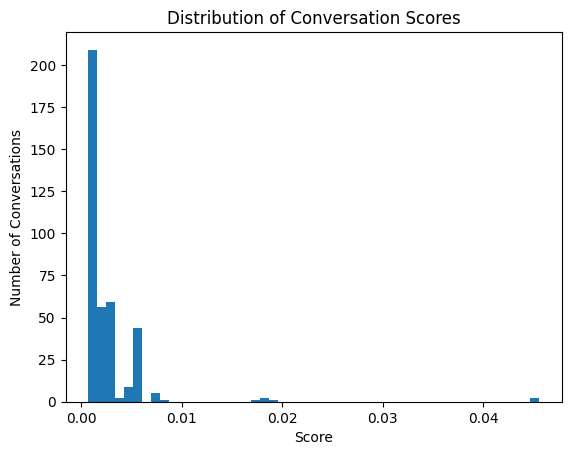

In [19]:
# Plot the distribution of scores
import matplotlib.pyplot as plt

scores = [conv.score for conv in conversations]
plt.hist(scores, bins=50)
plt.xlabel("Score")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Conversation Scores")
plt.show()

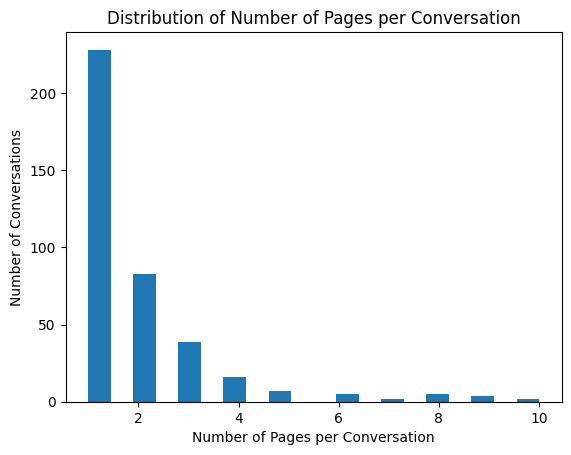

In [15]:
import matplotlib.pyplot as plt

# plot the distribution of number of pages per conversation
page_counts = [len(conv.pages) for conv in conversations]
plt.hist(page_counts, bins=20)
plt.xlabel("Number of Pages per Conversation")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Number of Pages per Conversation")
plt.show()

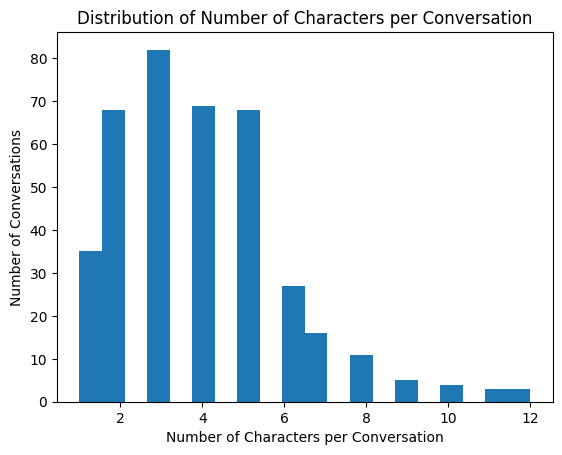

In [16]:
# Plot the distribution of number of characters per conversation
char_counts = [len(conv.characters) for conv in conversations]
plt.hist(char_counts, bins=20)
plt.xlabel("Number of Characters per Conversation")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Number of Characters per Conversation")
plt.show()

In [17]:
# What are the most common characters in the same conversation?
from collections import Counter

char_counter = Counter(
    ",".join(conv.characters)
    for conv in conversations
)
char_counter.most_common(20)

[('paperinik,uno', 54),
 ('everett ducklair,paperinik,uno', 36),
 ('paperinik', 11),
 ('uno', 10),
 ('everett ducklair,paperinik', 5),
 ('evroniano,paperinik,uno', 2),
 ('everett ducklair,paperinik,uno,woman with red hair', 2),
 ('angus fangus,everett ducklair,paperinik,uno,woman with dark curly hair', 1),
 ('everett ducklair,green alien,green robot,isaac (assistant robot),lyla lay,paperinik,red figure,red robot,scientist robot,sound effect,uno,woman in grey suit',
  1),
 ('green entity (virtual uno),paperinik,red-suited antagonist,uno', 1),
 ('blond character (luke skywalker parody),man with grey hair and beard,paperinik,uno',
  1),
 ('everett ducklair,lyla lay,muscular red duck,paperinik,red armored duck,red muscular creature,red muscular figure,uno,woman in grey armor',
  1),
 ('everett ducklair,paperinik,robot (blue),uno', 1),
 ('everett ducklair,guard,guard (left),guard (right),paperinik,scrooge mcduck,uno,younger duck in red shirt',
  1),
 ('everett ducklair,military figure,paper